# Uber Data Analysis Project

## Project Objective
The objective of this project is to analyze Uber ride data and identify patterns related to
ride category, purpose, time of booking, day-wise and month-wise trends, and distance travelled.


This analysis answers the following business questions:

1. In which category do people book Uber rides the most?
2. For which purpose do people book Uber rides the most?
3. At what time of the day are Uber rides booked the most?
4. In which months are Uber rides booked less frequently?
5. On which days of the week are Uber rides booked the most?
6. How many miles do people usually travel using Uber?



## Dataset Overview
- Dataset Name: UberDataset.csv
- Rows: 1156
- Columns: 7

### Key Columns
- START_DATE*: Ride start date and time
- END_DATE*: Ride end date and time
- CATEGORY*: Business / Personal
- START*: Start location
- STOP*: Stop location
- MILES*: Distance travelled
- PURPOSE*: Purpose of the ride


## Import Required Libraries
In this step, we import the Python libraries required for data manipulation,
analysis, and visualization.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Load the Dataset
The dataset is loaded into a pandas DataFrame to begin the analysis.


In [4]:
dataset=pd.read_csv("uber-dataset.csv")
dataset.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*
0,1/1/2016 21:11,1/1/2016 21:17,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain
1,1/2/2016 1:25,1/2/2016 1:37,Business,Fort Pierce,Fort Pierce,5.0,NaN
2,1/2/2016 20:25,1/2/2016 20:38,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies
3,1/5/2016 17:31,1/5/2016 17:45,Business,Fort Pierce,Fort Pierce,4.7,Meeting
4,1/6/2016 14:42,1/6/2016 15:49,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit


## Initial Data Inspection
This step helps understand the structure of the dataset, including
the number of rows, columns, data types, and missing values.

In [14]:
dataset.info()
dataset.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1156 entries, 0 to 1155
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   START_DATE*  1155 non-null   datetime64[ns]
 1   END_DATE*    1155 non-null   object        
 2   CATEGORY*    1155 non-null   object        
 3   START*       1155 non-null   object        
 4   STOP*        1155 non-null   object        
 5   MILES*       1156 non-null   float64       
 6   PURPOSE*     1156 non-null   object        
 7   date         1155 non-null   object        
 8   time         1155 non-null   float64       
dtypes: datetime64[ns](1), float64(2), object(6)
memory usage: 81.4+ KB


(1156, 9)

## Data Cleaning
Missing values in the dataset are handled to ensure accurate
and reliable analysis.

In [15]:
dataset['PURPOSE*'].fillna("NOT",inplace = True)

C:\Users\hp\AppData\Local\Temp\ipykernel_6804\4208619134.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  dataset['PURPOSE*'].fillna("NOT",inplace = True)


## Date-Time Conversion
The start and end date columns are converted into datetime format
to enable time-based analysis.

In [18]:
dataset['START_DATE*'] = pd.to_datetime(dataset['START_DATE*'], errors='coerce')
dataset['END_DATE*'] = pd.to_datetime(dataset['END_DATE*'], errors='coerce')

dataset.dropna(inplace=True)
dataset.info()


<class 'pandas.core.frame.DataFrame'>
Index: 1155 entries, 0 to 1154
Data columns (total 9 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   START_DATE*  1155 non-null   datetime64[ns]
 1   END_DATE*    1155 non-null   datetime64[ns]
 2   CATEGORY*    1155 non-null   object        
 3   START*       1155 non-null   object        
 4   STOP*        1155 non-null   object        
 5   MILES*       1155 non-null   float64       
 6   PURPOSE*     1155 non-null   object        
 7   date         1155 non-null   object        
 8   time         1155 non-null   float64       
dtypes: datetime64[ns](2), float64(2), object(5)
memory usage: 90.2+ KB


## Feature Engineering
New features such as date and time are extracted from the start date
to analyze ride patterns effectively.


In [19]:
dataset['date'] = dataset['START_DATE*'].dt.date
dataset['time'] = dataset['START_DATE*'].dt.hour


## Time of Day Classification
To understand ride demand during different parts of the day, the time
column is categorized into Morning, Afternoon, Evening, and Night.


In [20]:
dataset['day-night'] = pd.cut(
    x=dataset['time'],
    bins=[0,10,15,19,24],
    labels=['Morning','Afternoon','Evening','Night']
)


In [21]:
dataset.head()

,START_DATE*,END_DATE*,CATEGORY*,START*,STOP*,MILES*,PURPOSE*,date,time,day-night
0,2016-01-01 21:11:00,2016-01-01 21:17:00,Business,Fort Pierce,Fort Pierce,5.1,Meal/Entertain,2016-01-01,21,Night
1,2016-01-02 01:25:00,2016-01-02 01:37:00,Business,Fort Pierce,Fort Pierce,5.0,NOT,2016-01-02,1,Morning
2,2016-01-02 20:25:00,2016-01-02 20:38:00,Business,Fort Pierce,Fort Pierce,4.8,Errand/Supplies,2016-01-02,20,Night
3,2016-01-05 17:31:00,2016-01-05 17:45:00,Business,Fort Pierce,Fort Pierce,4.7,Meeting,2016-01-05,17,Evening
4,2016-01-06 14:42:00,2016-01-06 15:49:00,Business,Fort Pierce,West Palm Beach,63.7,Customer Visit,2016-01-06,14,Afternoon


## Category-wise Analysis
This analysis identifies which ride category is used most frequently.

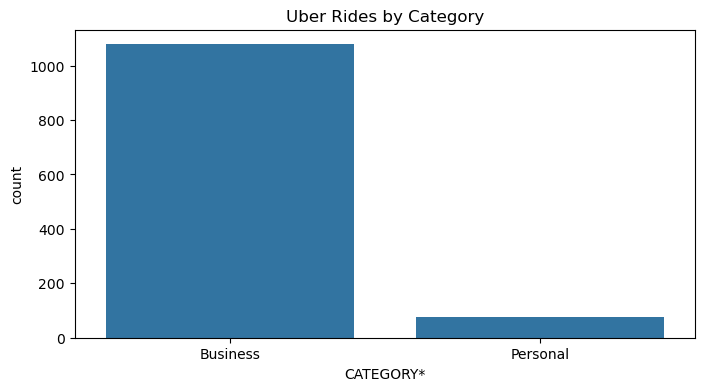

In [23]:
plt.figure(figsize=(8,4))
sns.countplot(x='CATEGORY*', data=dataset)
plt.title("Uber Rides by Category")
plt.show()

## Purpose-wise Analysis
This analysis highlights the most common purposes for booking Uber rides.


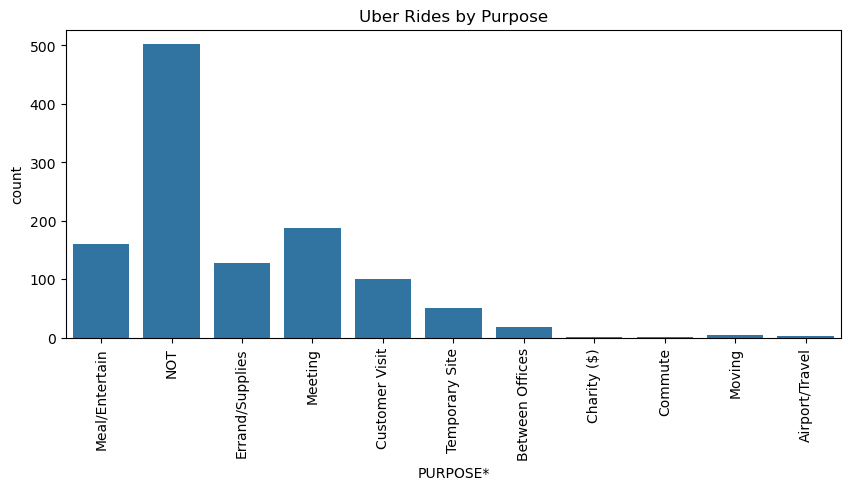

In [24]:
plt.figure(figsize=(10,4))
sns.countplot(x='PURPOSE*', data=dataset)
plt.xticks(rotation=90)
plt.title("Uber Rides by Purpose")
plt.show()

## Time of Day Analysis
This analysis shows at which time of day Uber rides are booked the most.


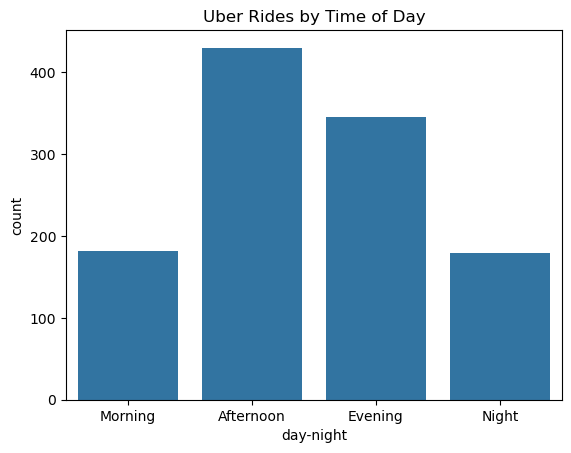

In [25]:
sns.countplot(x='day-night', data=dataset)
plt.title("Uber Rides by Time of Day")
plt.show()

## Month-wise Analysis
This analysis helps identify how Uber ride bookings vary across different months
and reveals any seasonal trends in ride demand.

In [28]:
dataset['MONTH'] = dataset['START_DATE*'].dt.month

In [29]:
month_label = {
    1:'Jan', 2:'Feb', 3:'Mar', 4:'Apr',
    5:'May', 6:'Jun', 7:'Jul', 8:'Aug',
    9:'Sep', 10:'Oct', 11:'Nov', 12:'Dec'
}

dataset['MONTH'] = dataset['MONTH'].map(month_label)

In [30]:
mon = dataset['MONTH'].value_counts(sort=False)
mon

MONTH
Jan     61
Feb    115
Mar    113
Apr     54
May     49
Jun    108
Jul    112
Aug    133
Sep     36
Oct    106
Nov    122
Dec    146
Name: count, dtype: int64

The following visualization shows the monthly trend of Uber rides.
It helps compare ride frequency and long-distance travel patterns across months.

In [ ]:
dataset['Day']=dataset.

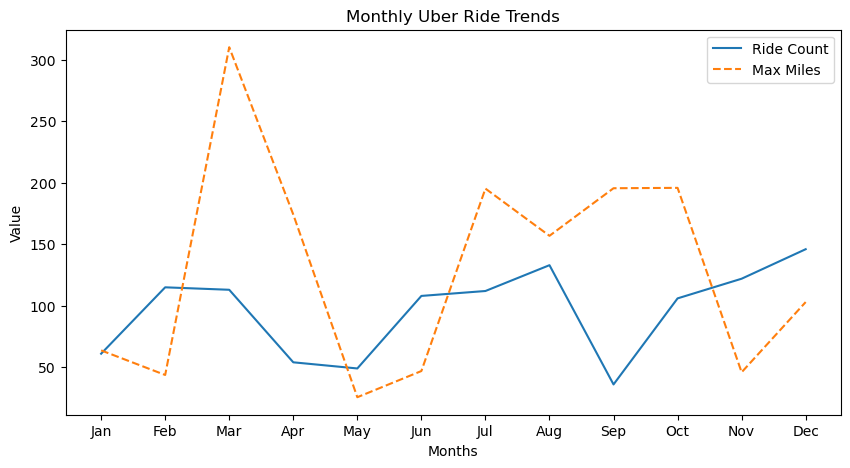

In [31]:
df = pd.DataFrame({
    'MONTHS': mon.index,
    'VALUE_COUNT': mon.values,
    'MAX_MILES': dataset.groupby('MONTH', sort=False)['MILES*'].max().values
})

plt.figure(figsize=(10,5))
sns.lineplot(x='MONTHS', y='VALUE_COUNT', data=df, label='Ride Count')
sns.lineplot(x='MONTHS', y='MAX_MILES', data=df, linestyle='--', label='Max Miles')

plt.xlabel('Months')
plt.ylabel('Value')
plt.title('Monthly Uber Ride Trends')
plt.legend()
plt.show()


## Day-wise Analysis
This analysis identifies which days of the week have the highest number
of Uber ride bookings.

In [32]:
dataset['DAY'] = dataset['START_DATE*'].dt.weekday

day_map = {
    0:'Mon', 1:'Tues', 2:'Wed', 3:'Thur',
    4:'Fri', 5:'Sat', 6:'Sun'
}

dataset['DAY'] = dataset['DAY'].map(day_map)


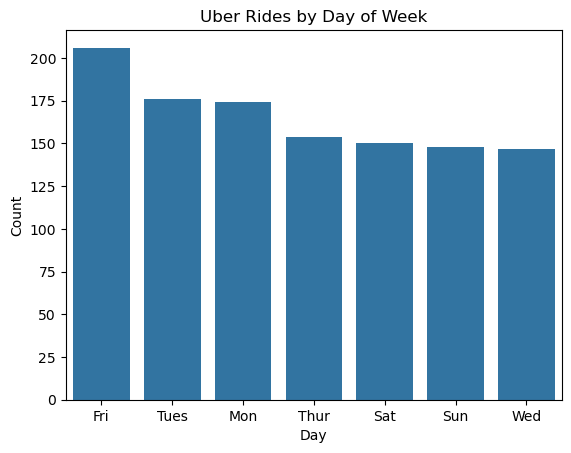

In [33]:
day_count = dataset['DAY'].value_counts()

sns.barplot(x=day_count.index, y=day_count.values)
plt.xlabel("Day")
plt.ylabel("Count")
plt.title("Uber Rides by Day of Week")
plt.show()


## Distance (Miles) Analysis
This analysis helps understand how far users usually travel using Uber.
Boxplots are used to identify typical ride distances and detect outliers.


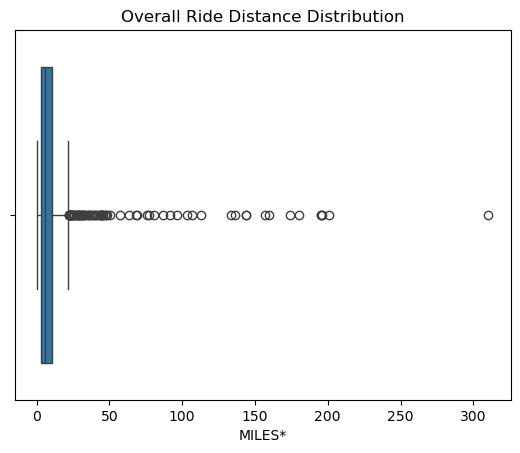

In [34]:
sns.boxplot(x=dataset['MILES*'])
plt.title("Overall Ride Distance Distribution")
plt.show()


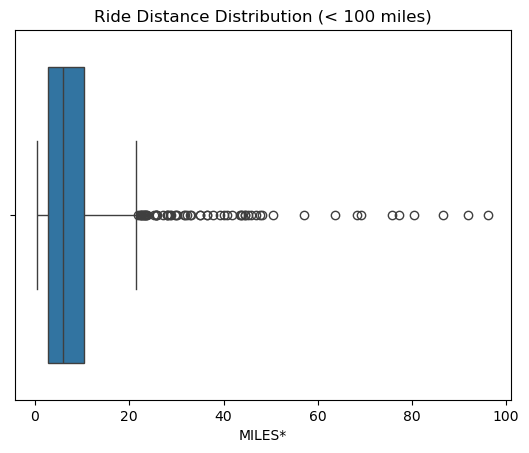

In [35]:
sns.boxplot(x=dataset[dataset['MILES*'] < 100]['MILES*'])
plt.title("Ride Distance Distribution (< 100 miles)")
plt.show()


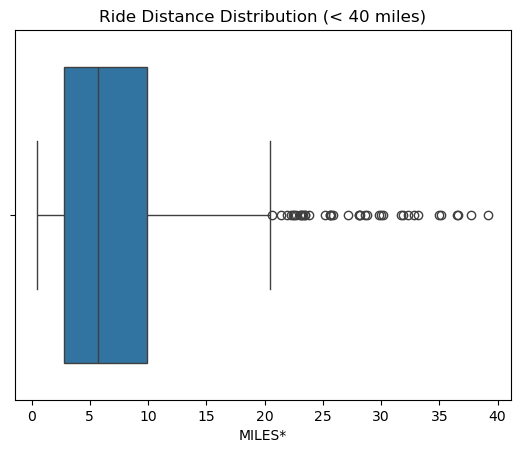

In [36]:
sns.boxplot(x=dataset[dataset['MILES*'] < 40]['MILES*'])
plt.title("Ride Distance Distribution (< 40 miles)")
plt.show()


To better visualize the distribution of common ride distances,
a histogram is plotted after removing extreme outliers.


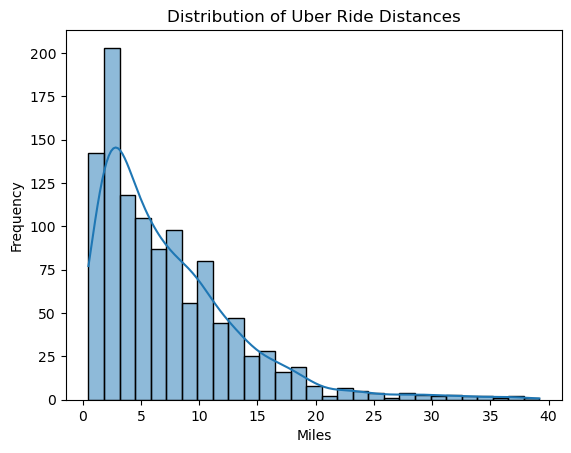

In [37]:
sns.histplot(dataset[dataset['MILES*'] < 40]['MILES*'], kde=True)
plt.title("Distribution of Uber Ride Distances")
plt.xlabel("Miles")
plt.ylabel("Frequency")
plt.show()


## Key Insights
- Business category accounts for the majority of Uber rides.
- Most rides are booked for work-related purposes.
- Afternoon is the peak time for Uber bookings.
- Ride activity varies across different months.
- Fridays have the highest number of Uber rides.
- Most Uber rides are short-distance trips, generally between 2 and 10 miles.

## Conclusion
This project demonstrates how exploratory data analysis techniques can be
used to analyze real-world Uber ride data. By examining ride patterns across
time, category, and distance, meaningful insights were derived that can help
understand user behavior and booking trends.
